In [1]:
# ============================================================
# CELL 1 — PROJECT SETUP AND REQUIRED LIBRARIES
# ============================================================

from pathlib import Path
import sys

import pandas as pd

# The notebook is inside the notebooks/ folder.
# Therefore, the project root is one level above it.
PROJECT_ROOT = Path.cwd().parent

# Add the project root to Python's import path.
#
# This allows the notebook to import reusable modules
# from the src/ folder.
sys.path.append(str(PROJECT_ROOT))

# Import the resolution-independent SOLETE data loader.
#
# The same loader can load:
#   - 60-minute data
#   - 5-minute data
#   - 1-minute data
#   - 1-second data
#
# The resolution is determined by the HDF5 file that
# we provide to the loader.
from src.data_loader import load_solete

In [2]:
# ============================================================
# CELL 2 — LOAD THE 5-MINUTE SOLETE DATASET
# ============================================================

# Path to the 5-minute SOLETE HDF5 file.
dataset_path = Path("../solete_dataset/SOLETE_Pombo_5min.h5")

# Load the dataset using our reusable SOLETE loader.
#
# The loader automatically reads the structure of the HDF5 file.
# Here, the selected file determines that we are working with
# the 5-minute resolution dataset.
df = load_solete(dataset_path)

# Display the DataFrame so we can visually inspect
# the loaded data.
df

,TEMPERATURE[degC],HUMIDITY[%],WIND_SPEED[m1s],WIND_DIR[deg],GHI[kW1m2],POA Irr[kW1m2],P_Gaia[kW],P_Solar[kW],Pressure[mbar],Azimuth[deg],Elevation[deg]
Timestamp,,,,,,,,,,,
2018-06-01 00:00:00+00:00,14.561204,0.7,1.293645,111.635452,0.0,0.0,0.046917,0.0,1017.559985,0.0,0.0
2018-06-01 00:05:00+00:00,14.487667,0.7,1.442333,91.236667,0.0,0.0,0.000267,0.0,1017.539990,0.0,0.0
2018-06-01 00:10:00+00:00,14.400000,0.7,1.408667,104.423333,0.0,0.0,0.000000,0.0,1017.493668,0.0,0.0
2018-06-01 00:15:00+00:00,14.240000,0.7,1.379333,103.976667,0.0,0.0,0.039050,0.0,1017.466342,0.0,0.0
2018-06-01 00:20:00+00:00,14.200000,0.7,1.453333,96.606667,0.0,0.0,0.003157,0.0,1017.533658,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2019-08-31 23:40:00+00:00,20.372667,0.8,1.437333,110.796667,0.0,0.0,0.000000,0.0,1005.659985,0.0,0.0
2019-08-31 23:45:00+00:00,20.577000,0.8,1.396667,108.786667,0.0,0.0,0.000000,0.0,1005.706000,0.0,0.0
2019-08-31 23:50:00+00:00,20.567000,0.8,1.466333,107.963333,0.0,0.0,0.000000,0.0,1005.723008,0.0,0.0


In [3]:
# ============================================================
# CELL 3 — BASIC DATASET INFORMATION
# ============================================================

# Display the dimensions of the dataset.
# This confirms the number of observations (rows)
# and measured variables (columns).
print("Dataset shape:")
print(df.shape)

# Display the column names.
# This helps us confirm exactly which measurements
# are available in the 5-minute dataset.
print("\nColumn names:")
for column in df.columns:
    print("-", column)

# Display information about the DataFrame:
#   - column names
#   - data types
#   - number of non-null values
print("\nDataFrame information:")
df.info()

Dataset shape:
(131617, 11)

Column names:
- TEMPERATURE[degC]
- HUMIDITY[%]
- WIND_SPEED[m1s]
- WIND_DIR[deg]
- GHI[kW1m2]
- POA Irr[kW1m2]
- P_Gaia[kW]
- P_Solar[kW]
- Pressure[mbar]
- Azimuth[deg]
- Elevation[deg]

DataFrame information:
<class 'pandas.DataFrame'>
DatetimeIndex: 131617 entries, 2018-06-01 00:00:00+00:00 to 2019-09-01 00:00:00+00:00
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   TEMPERATURE[degC]  131617 non-null  float64
 1   HUMIDITY[%]        131617 non-null  float64
 2   WIND_SPEED[m1s]    131617 non-null  float64
 3   WIND_DIR[deg]      131617 non-null  float64
 4   GHI[kW1m2]         131617 non-null  float64
 5   POA Irr[kW1m2]     131617 non-null  float64
 6   P_Gaia[kW]         131617 non-null  float64
 7   P_Solar[kW]        131617 non-null  float64
 8   Pressure[mbar]     131617 non-null  float64
 9   Azimuth[deg]       131617 non-null  float64
 10  Elevation[deg]     1

In [4]:
# ============================================================
# CELL 4 — CHECK FOR MISSING VALUES
# ============================================================

# Count the number of missing (NaN) values in each column.
#
# Missing values are important in time-series forecasting
# because they can create gaps in the input sequence.
missing_values = df.isna().sum()

print("Missing values in each column:")
print(missing_values)

# Check whether the entire dataset contains any missing values.
total_missing = missing_values.sum()

print("\nTotal missing values in the dataset:")
print(total_missing)

Missing values in each column:
TEMPERATURE[degC]    0
HUMIDITY[%]          0
WIND_SPEED[m1s]      0
WIND_DIR[deg]        0
GHI[kW1m2]           0
POA Irr[kW1m2]       0
P_Gaia[kW]           0
P_Solar[kW]          0
Pressure[mbar]       0
Azimuth[deg]         0
Elevation[deg]       0
dtype: int64

Total missing values in the dataset:
0


In [5]:
# ============================================================
# CELL 5 — CHECK FOR DUPLICATE TIMESTAMPS
# ============================================================

# Check whether any timestamps appear more than once.
#
# A duplicate timestamp would mean that multiple observations
# are assigned to the same point in time, which could cause
# problems when building forecasting sequences later.
duplicate_timestamps = df.index.duplicated().sum()

print("Number of duplicate timestamps:")
print(duplicate_timestamps)

# Also check whether the entire timestamp index is unique.
print("\nAre all timestamps unique?")
print(df.index.is_unique)

Number of duplicate timestamps:
0

Are all timestamps unique?
True


In [6]:
# ============================================================
# CELL 6 — CHECK TIMESTAMP ORDERING
# ============================================================

# Check whether the timestamps are already sorted
# from earliest to latest.
#
# This is different from checking duplicates:
# a dataset can have unique timestamps but still have
# observations stored in the wrong order.
timestamps_sorted = df.index.is_monotonic_increasing

print("Are timestamps in chronological order?")
print(timestamps_sorted)

Are timestamps in chronological order?
True


In [7]:
# ============================================================
# CELL 7 — CHECK TIME INTERVALS
# ============================================================

# Calculate the time difference between every consecutive
# timestamp in the dataset.
#
# For a correctly sampled 5-minute dataset, we expect
# every consecutive difference to be exactly 5 minutes.
time_differences = df.index.to_series().diff()

# Count how many times each time interval occurs.
interval_counts = time_differences.value_counts()

print("Most common time intervals:")
print(interval_counts.head(10))

# Count observations that do NOT have the expected 5-minute interval.
unexpected_intervals = (
    time_differences.iloc[1:] != pd.Timedelta(minutes=5)
).sum()

print("\nNumber of unexpected time intervals:")
print(unexpected_intervals)

Most common time intervals:
Timestamp
0 days 00:05:00    131616
Name: count, dtype: int64

Number of unexpected time intervals:
0


In [8]:
# ============================================================
# CELL 8 — BASIC STATISTICAL SUMMARY
# ============================================================

# Generate descriptive statistics for all numerical columns.
#
# We will inspect:
#   - count
#   - mean
#   - standard deviation
#   - minimum
#   - 25th percentile
#   - median (50%)
#   - 75th percentile
#   - maximum
#
# At this stage we are NOT modifying the data.
# We are only trying to understand its distribution.
summary_statistics = df.describe().T

# Display the summary.
summary_statistics

,count,mean,std,min,25%,50%,75%,max
TEMPERATURE[degC],131617.0,11.936593,7.223151,-4.814333,5.674667,12.509000,17.526000,44.535452
HUMIDITY[%],131617.0,0.769125,0.158512,0.000000,0.700000,0.800000,0.900000,2.000000
WIND_SPEED[m1s],131617.0,3.591904,2.107510,0.000000,2.064000,3.287333,4.684667,24.393980
WIND_DIR[deg],131617.0,209.155515,72.642820,0.000000,145.796667,215.920000,276.343333,680.000000
GHI[kW1m2],131617.0,0.140382,0.218480,0.000000,0.000000,0.011147,0.207863,1.092413
POA Irr[kW1m2],131617.0,0.144382,0.245790,0.000000,0.000000,0.009047,0.168813,1.119663
P_Gaia[kW],131617.0,2.694643,3.382534,0.000000,0.000000,0.985330,4.677300,23.330538
P_Solar[kW],131617.0,0.987980,1.666584,0.000000,0.000000,0.070956,1.185170,7.715423
Pressure[mbar],131617.0,1013.775905,59.362014,974.262999,1000.000000,1010.903013,1016.746338,2034.519662
Azimuth[deg],131617.0,-2.131780,57.375601,-152.374530,-25.085280,0.000000,17.782020,145.346370


In [9]:
# ============================================================
# CELL 9 — RANGE / VALIDITY SCREENING
# ============================================================

# This cell does NOT modify the dataset.
#
# It only counts observations that fall outside
# physically or logically expected ranges.

checks = {
    "Temperature < -50°C": (
        df["TEMPERATURE[degC]"] < -50
    ).sum(),

    "Temperature > 60°C": (
        df["TEMPERATURE[degC]"] > 60
    ).sum(),

    "Humidity < 0": (
        df["HUMIDITY[%]"] < 0
    ).sum(),

    "Humidity > 100": (
        df["HUMIDITY[%]"] > 100
    ).sum(),

    "Wind speed < 0": (
        df["WIND_SPEED[m1s]"] < 0
    ).sum(),

    "Wind direction < 0°": (
        df["WIND_DIR[deg]"] < 0
    ).sum(),

    "Wind direction > 360°": (
        df["WIND_DIR[deg]"] > 360
    ).sum(),

    "GHI < 0": (
        df["GHI[kW1m2]"] < 0
    ).sum(),

    "POA irradiance < 0": (
        df["POA Irr[kW1m2]"] < 0
    ).sum(),

    "Gaia power < 0": (
        df["P_Gaia[kW]"] < 0
    ).sum(),

    "Solar power < 0": (
        df["P_Solar[kW]"] < 0
    ).sum(),

    "Pressure < 800 mbar": (
        df["Pressure[mbar]"] < 800
    ).sum(),

    "Pressure > 1100 mbar": (
        df["Pressure[mbar]"] > 1100
    ).sum(),

    "Elevation < -90°": (
        df["Elevation[deg]"] < -90
    ).sum(),

    "Elevation > 90°": (
        df["Elevation[deg]"] > 90
    ).sum(),
}

# Convert the results into a readable Series.
range_screening = pd.Series(checks)

print("Potentially suspicious observations:")
print(range_screening)

Potentially suspicious observations:
Temperature < -50°C        0
Temperature > 60°C         0
Humidity < 0               0
Humidity > 100             0
Wind speed < 0             0
Wind direction < 0°        0
Wind direction > 360°    103
GHI < 0                    0
POA irradiance < 0         0
Gaia power < 0             0
Solar power < 0            0
Pressure < 800 mbar        0
Pressure > 1100 mbar     456
Elevation < -90°           0
Elevation > 90°            0
dtype: int64


In [10]:
# ============================================================
# CELL 10 — INVESTIGATE WIND DIRECTION VALUES ABOVE 360°
# ============================================================

# Select wind-direction values that are outside the
# conventional 0°–360° range.
#
# We are only inspecting these values here.
# The original dataset is NOT being modified.
invalid_wind_direction = df.loc[
    df["WIND_DIR[deg]"] > 360,
    "WIND_DIR[deg]"
]

print("Number of wind-direction values above 360°:")
print(len(invalid_wind_direction))

print("\nOriginal wind-direction range:")
print(
    df["WIND_DIR[deg]"].min(),
    "to",
    df["WIND_DIR[deg]"].max()
)

# Convert the suspicious values using modulo 360.
#
# Example:
#   680° % 360 = 320°
#
# This is a diagnostic only. We are NOT replacing
# the original values.
wind_direction_modulo = invalid_wind_direction % 360

print("\nRange after modulo-360 transformation:")
print(
    wind_direction_modulo.min(),
    "to",
    wind_direction_modulo.max()
)

# Show a few examples of the original value
# and its wrapped equivalent.
wind_direction_examples = pd.DataFrame({
    "original": invalid_wind_direction.head(10),
    "modulo_360": wind_direction_modulo.head(10)
})

print("\nExamples:")
wind_direction_examples

Number of wind-direction values above 360°:
103

Original wind-direction range:
0.0 to 680.0

Range after modulo-360 transformation:
0.2976588628762329 to 320.0

Examples:


,original,modulo_360
Timestamp,,
2018-06-04 00:00:00+00:00,531.528428,171.528428
2018-06-12 00:00:00+00:00,565.193980,205.193980
2018-06-13 00:00:00+00:00,489.896321,129.896321
2018-06-14 00:00:00+00:00,470.468227,110.468227
2018-06-18 00:00:00+00:00,457.521739,97.521739
2018-06-21 00:00:00+00:00,449.832776,89.832776
2018-06-22 00:00:00+00:00,538.444816,178.444816
2018-06-24 00:00:00+00:00,468.147157,108.147157
2018-06-29 00:00:00+00:00,528.739130,168.739130


In [11]:
# ============================================================
# CELL 11 — INVESTIGATE SUSPICIOUS PRESSURE VALUES
# ============================================================

# Select pressure observations above 1100 mbar.
#
# We are only inspecting these values.
# The original dataset is NOT being modified.
suspicious_pressure = df.loc[
    df["Pressure[mbar]"] > 1100,
    "Pressure[mbar]"
]

print("Number of pressure values above 1100 mbar:")
print(len(suspicious_pressure))

print("\nRange of suspicious pressure values:")
print(
    suspicious_pressure.min(),
    "to",
    suspicious_pressure.max()
)

print("\nMost common suspicious pressure values:")
print(suspicious_pressure.value_counts().head(20))

print("\nExample suspicious pressure observations:")
print(suspicious_pressure.head(20))

Number of pressure values above 1100 mbar:
456

Range of suspicious pressure values:
1986.8800170898442 to 2034.5196618652349

Most common suspicious pressure values:
Pressure[mbar]
2000.000000    223
2017.880017      2
2025.480005      2
2013.659998      1
2013.420020      1
2011.500000      1
2007.450345      1
2015.010331      1
2017.840002      1
2014.500000      1
2013.599976      1
2011.733004      1
2007.667000      1
2004.480005      1
2006.019995      1
2010.036324      1
2009.972673      1
2015.420020      1
2011.059331      1
2014.219662      1
Name: count, dtype: int64

Example suspicious pressure observations:
Timestamp
2018-06-02 00:00:00+00:00    2013.659998
2018-06-03 00:00:00+00:00    2013.420020
2018-06-04 00:00:00+00:00    2011.500000
2018-06-05 00:00:00+00:00    2007.450345
2018-06-06 00:00:00+00:00    2015.010331
2018-06-07 00:00:00+00:00    2017.840002
2018-06-08 00:00:00+00:00    2014.500000
2018-06-09 00:00:00+00:00    2013.599976
2018-06-10 00:00:00+00:00    20

In [12]:
# ============================================================
# CELL 12 — INVESTIGATE THE TIME PATTERN OF SUSPICIOUS PRESSURE
# ============================================================

# Select timestamps where pressure is above 1100 mbar.
suspicious_pressure_rows = df.loc[
    df["Pressure[mbar]"] > 1100,
    ["Pressure[mbar]"]
]

print("First suspicious pressure observations:")
print(suspicious_pressure_rows.head(20))

print("\nLast suspicious pressure observations:")
print(suspicious_pressure_rows.tail(20))

# Check which calendar dates contain suspicious pressure values.
suspicious_dates = suspicious_pressure_rows.index.normalize().unique()

print("\nNumber of different dates containing suspicious pressure:")
print(len(suspicious_dates))

print("\nFirst 20 dates containing suspicious pressure:")
print(suspicious_dates[:20])

print("\nLast 20 dates containing suspicious pressure:")
print(suspicious_dates[-20:])

First suspicious pressure observations:
                           Pressure[mbar]
Timestamp                                
2018-06-02 00:00:00+00:00     2013.659998
2018-06-03 00:00:00+00:00     2013.420020
2018-06-04 00:00:00+00:00     2011.500000
2018-06-05 00:00:00+00:00     2007.450345
2018-06-06 00:00:00+00:00     2015.010331
2018-06-07 00:00:00+00:00     2017.840002
2018-06-08 00:00:00+00:00     2014.500000
2018-06-09 00:00:00+00:00     2013.599976
2018-06-10 00:00:00+00:00     2011.733004
2018-06-11 00:00:00+00:00     2007.667000
2018-06-12 00:00:00+00:00     2004.480005
2018-06-13 00:00:00+00:00     2006.019995
2018-06-14 00:00:00+00:00     2010.036324
2018-06-15 00:00:00+00:00     2009.972673
2018-06-16 00:00:00+00:00     2015.420020
2018-06-17 00:00:00+00:00     2011.059331
2018-06-18 00:00:00+00:00     2014.219662
2018-06-19 00:00:00+00:00     2012.799667
2018-06-20 00:00:00+00:00     2018.134002
2018-06-21 00:00:00+00:00     2008.656996

Last suspicious pressure observatio

In [13]:
# ============================================================
# CELL 13 — COMPARE SUSPICIOUS MIDNIGHT PRESSURE VALUES
# ============================================================

# Select a small time window around the first suspicious
# pressure observation.
#
# We use 2018-06-01 to 2018-06-03 so that we can compare
# the suspicious midnight values with the surrounding
# 5-minute observations.

pressure_window = df.loc[
    "2018-06-01":"2018-06-03",
    ["Pressure[mbar]"]
]

print("Pressure around the first suspicious period:")
print(pressure_window.head(30))

print("\nPressure values around 2018-06-02 00:00:")
print(
    pressure_window.loc[
        "2018-06-01 23:30:00+00:00":
        "2018-06-02 00:30:00+00:00"
    ]
)

Pressure around the first suspicious period:
                           Pressure[mbar]
Timestamp                                
2018-06-01 00:00:00+00:00     1017.559985
2018-06-01 00:05:00+00:00     1017.539990
2018-06-01 00:10:00+00:00     1017.493668
2018-06-01 00:15:00+00:00     1017.466342
2018-06-01 00:20:00+00:00     1017.533658
2018-06-01 00:25:00+00:00     1017.546322
2018-06-01 00:30:00+00:00     1017.513663
2018-06-01 00:35:00+00:00     1017.453678
2018-06-01 00:40:00+00:00     1017.440015
2018-06-01 00:45:00+00:00     1017.393677
2018-06-01 00:50:00+00:00     1017.400012
2018-06-01 00:55:00+00:00     1017.340002
2018-06-01 01:00:00+00:00     1017.320007
2018-06-01 01:05:00+00:00     1017.299988
2018-06-01 01:10:00+00:00     1017.340002
2018-06-01 01:15:00+00:00     1017.279993
2018-06-01 01:20:00+00:00     1017.299988
2018-06-01 01:25:00+00:00     1017.299988
2018-06-01 01:30:00+00:00     1017.233671
2018-06-01 01:35:00+00:00     1017.220007
2018-06-01 01:40:00+00:00     1

In [14]:
# ============================================================
# CELL 14 — ZERO AND NON-ZERO POWER OBSERVATIONS
# ============================================================

# Count how many observations have zero power generation.
#
# Zero production is expected:
#   - Solar power can be zero during nighttime.
#   - Wind power can be zero when there is insufficient wind.
solar_zero = (df["P_Solar[kW]"] == 0).sum()
gaia_zero = (df["P_Gaia[kW]"] == 0).sum()

# Calculate the percentage of zero-power observations.
solar_zero_percent = solar_zero / len(df) * 100
gaia_zero_percent = gaia_zero / len(df) * 100

print("P_Solar zero observations:")
print(solar_zero)

print("P_Solar zero percentage:")
print(f"{solar_zero_percent:.2f}%")

print("\nP_Gaia zero observations:")
print(gaia_zero)

print("P_Gaia zero percentage:")
print(f"{gaia_zero_percent:.2f}%")

# Also display the basic non-zero statistics.
print("\nP_Solar non-zero observations:")
print((df["P_Solar[kW]"] > 0).sum())

print("\nP_Gaia non-zero observations:")
print((df["P_Gaia[kW]"] > 0).sum())

P_Solar zero observations:
54303
P_Solar zero percentage:
41.26%

P_Gaia zero observations:
38812
P_Gaia zero percentage:
29.49%

P_Solar non-zero observations:
77314

P_Gaia non-zero observations:
92805


In [15]:
# ============================================================
# CELL 15 — SOLAR POWER AND SUN ELEVATION
# ============================================================

# Create a small table containing:
#   - solar power
#   - sun elevation
#
# We want to check whether zero solar generation generally
# occurs when the sun is below the horizon.
solar_elevation_check = df[
    [
        "P_Solar[kW]",
        "Elevation[deg]"
    ]
].copy()

# Count zero-solar-power observations where the sun is
# below the horizon.
#
# Elevation < 0° means the sun is geometrically below
# the horizon.
zero_solar_below_horizon = (
    (solar_elevation_check["P_Solar[kW]"] == 0)
    &
    (solar_elevation_check["Elevation[deg]"] < 0)
).sum()

# Count zero-solar-power observations where the sun is
# at or above the horizon.
zero_solar_above_horizon = (
    (solar_elevation_check["P_Solar[kW]"] == 0)
    &
    (solar_elevation_check["Elevation[deg]"] >= 0)
).sum()

print("Zero solar-power observations with sun below horizon:")
print(zero_solar_below_horizon)

print("\nZero solar-power observations with sun at/above horizon:")
print(zero_solar_above_horizon)

# Also calculate the total number of observations where
# the sun is below the horizon.
sun_below_horizon = (
    solar_elevation_check["Elevation[deg]"] < 0
).sum()

print("\nTotal observations with sun below horizon:")
print(sun_below_horizon)

Zero solar-power observations with sun below horizon:
0

Zero solar-power observations with sun at/above horizon:
54303

Total observations with sun below horizon:
0


In [16]:
# ============================================================
# CELL 16 — SOLAR POWER VS ZERO SOLAR ELEVATION
# ============================================================

# Count observations where solar power is exactly zero
# AND solar elevation is exactly zero.
#
# If these numbers match closely, it suggests that the
# dataset uses Elevation = 0° to represent nighttime
# or periods without positive solar elevation.
zero_power_zero_elevation = (
    (df["P_Solar[kW]"] == 0)
    &
    (df["Elevation[deg]"] == 0)
).sum()

# Count observations where solar power is non-zero
# but elevation is zero.
#
# These observations are especially interesting because
# they may represent low-light conditions, measurement
# behavior near sunrise/sunset, or another characteristic
# of the dataset.
nonzero_power_zero_elevation = (
    (df["P_Solar[kW]"] > 0)
    &
    (df["Elevation[deg]"] == 0)
).sum()

# Count all observations where elevation is exactly zero.
zero_elevation = (
    df["Elevation[deg]"] == 0
).sum()

print("Zero solar power AND zero elevation:")
print(zero_power_zero_elevation)

print("\nNon-zero solar power AND zero elevation:")
print(nonzero_power_zero_elevation)

print("\nTotal zero-elevation observations:")
print(zero_elevation)

Zero solar power AND zero elevation:
50658

Non-zero solar power AND zero elevation:
10387

Total zero-elevation observations:
61045


In [17]:
# ============================================================
# CELL 17 — TIME-OF-DAY PATTERN OF ZERO SOLAR ELEVATION
# ============================================================

# Create a copy containing only the solar elevation column.
elevation_time_check = df[
    ["Elevation[deg]"]
].copy()

# Extract the hour from each timestamp.
#
# We use UTC because the SOLETE timestamps are stored
# as UTC timestamps.
elevation_time_check["hour"] = (
    elevation_time_check.index.hour
)

# For each hour of the day, calculate:
#   - total number of observations
#   - number of observations with Elevation = 0
#
# This helps us see whether zero elevation is associated
# with particular times of day.
hourly_elevation_summary = (
    elevation_time_check
    .groupby("hour")
    .agg(
        total_observations=("Elevation[deg]", "size"),
        zero_elevation=(
            "Elevation[deg]",
            lambda x: (x == 0).sum()
        )
    )
)

# Calculate the percentage of observations with
# zero elevation for each hour.
hourly_elevation_summary["zero_elevation_percent"] = (
    hourly_elevation_summary["zero_elevation"]
    / hourly_elevation_summary["total_observations"]
    * 100
)

# Display the hourly summary.
hourly_elevation_summary

,total_observations,zero_elevation,zero_elevation_percent
hour,,,
0,5485,5485,100.000000
1,5484,5484,100.000000
2,5484,5484,100.000000
3,5484,4855,88.530270
4,5484,3502,63.858497
5,5484,2621,47.793581
6,5484,1994,36.360321
7,5484,1378,25.127644
8,5484,599,10.922684


In [18]:
# ============================================================
# CELL 18 — UNIQUE / REPRESENTATIVE SOLAR ELEVATION VALUES
# ============================================================

# Get the unique values of solar elevation.
#
# We are interested in understanding how the dataset
# represents the transition between zero and non-zero
# solar elevation.
unique_elevation = df["Elevation[deg]"].unique()

print("Number of unique elevation values:")
print(len(unique_elevation))

# Get the sorted UNIQUE positive elevation values.
positive_elevation_unique = (
    df.loc[
        df["Elevation[deg]"] > 0,
        "Elevation[deg]"
    ]
    .drop_duplicates()
    .sort_values()
)

print("Smallest unique positive elevation values:")
print(
    positive_elevation_unique
    .head(20)
    .to_list()
)

print("\nLargest unique elevation values:")
print(
    positive_elevation_unique
    .tail(20)
    .to_list()
)

Number of unique elevation values:
70330
Smallest unique positive elevation values:
[2.9999998708566e-05, 5.9999997417132e-05, 0.00026999998837709397, 0.000359999984502792, 0.0003899999894201754, 0.0005399999767541879, 0.0006899999765058353, 0.000719999969005584, 0.0008399999638398481, 0.001110000008096298, 0.0013500000163912777, 0.001379999940594036, 0.001409999995181958, 0.0016500000034769377, 0.0016799999276796962, 0.0019499999284744245, 0.001950000027815499, 0.0019799999271829906, 0.0022500000769893323, 0.002279999914268651]

Largest unique elevation values:
[57.78825002034509, 57.805920753479015, 57.81468041737877, 57.82014097849529, 57.8250007629395, 57.82572001139325, 57.84219006856285, 57.856889826456715, 57.862439880371106, 57.8699989318848, 57.95922008514403, 57.97670998891195, 58.02216009775796, 58.08566993713378, 58.12016988118487, 58.16855985005693, 58.19391028086342, 58.22594989776609, 58.257539901733374, 58.263029212951636]


In [19]:
# ============================================================
# CELL 19 — INSPECT SOLAR ELEVATION AROUND SUNRISE/SUNSET
# ============================================================

# Select one representative day from the dataset.
#
# We will inspect the solar elevation throughout this day
# to understand how the dataset represents:
#   - nighttime
#   - sunrise
#   - daytime
#   - sunset
#
# We are NOT modifying the dataset.

sample_day = df.loc[
    "2018-06-15",
    ["Elevation[deg]", "P_Solar[kW]"]
]

# Display the first observations of the day.
#
# These should show the behavior around the beginning
# of the day, when the sun is near/below the horizon.
print("Beginning of 2018-06-15:")
print(sample_day.head(20))

# Display the observations around the period where
# elevation first becomes positive.
#
# We find the first timestamp where elevation > 0.
first_positive_elevation = sample_day[
    sample_day["Elevation[deg]"] > 0
].index[0]

print("\nFirst positive elevation:")
print(first_positive_elevation)

print("\nObservations around first positive elevation:")
print(
    sample_day.loc[
        first_positive_elevation - pd.Timedelta(minutes=30):
        first_positive_elevation + pd.Timedelta(minutes=30)
    ]
)

# Find the last timestamp where elevation is positive.
last_positive_elevation = sample_day[
    sample_day["Elevation[deg]"] > 0
].index[-1]

print("\nLast positive elevation:")
print(last_positive_elevation)

print("\nObservations around last positive elevation:")
print(
    sample_day.loc[
        last_positive_elevation - pd.Timedelta(minutes=30):
        last_positive_elevation + pd.Timedelta(minutes=30)
    ]
)

Beginning of 2018-06-15:
                           Elevation[deg]  P_Solar[kW]
Timestamp                                             
2018-06-15 00:00:00+00:00             0.0          0.0
2018-06-15 00:05:00+00:00             0.0          0.0
2018-06-15 00:10:00+00:00             0.0          0.0
2018-06-15 00:15:00+00:00             0.0          0.0
2018-06-15 00:20:00+00:00             0.0          0.0
2018-06-15 00:25:00+00:00             0.0          0.0
2018-06-15 00:30:00+00:00             0.0          0.0
2018-06-15 00:35:00+00:00             0.0          0.0
2018-06-15 00:40:00+00:00             0.0          0.0
2018-06-15 00:45:00+00:00             0.0          0.0
2018-06-15 00:50:00+00:00             0.0          0.0
2018-06-15 00:55:00+00:00             0.0          0.0
2018-06-15 01:00:00+00:00             0.0          0.0
2018-06-15 01:05:00+00:00             0.0          0.0
2018-06-15 01:10:00+00:00             0.0          0.0
2018-06-15 01:15:00+00:00             0.

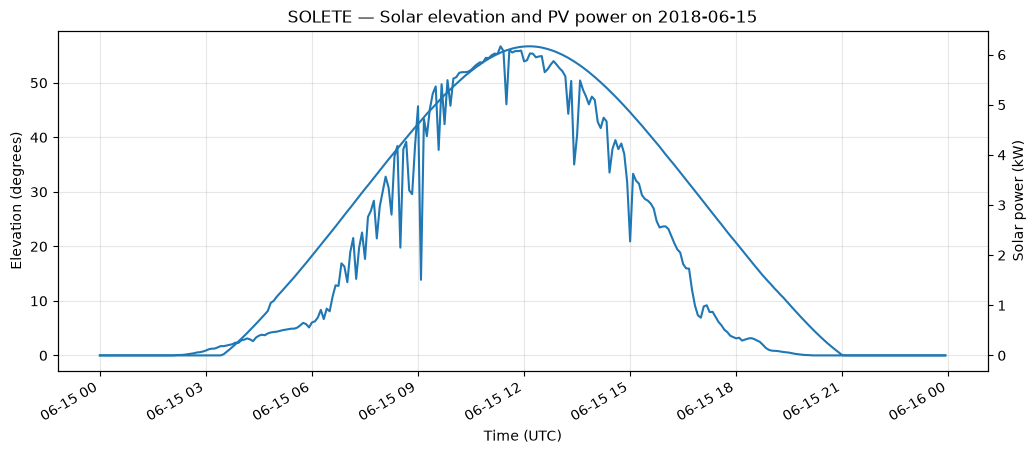

In [20]:
# ============================================================
# CELL 20 — PLOT SOLAR ELEVATION AND PV POWER
# ============================================================

import matplotlib.pyplot as plt

# Select the same representative day used above.
sample_day = df.loc[
    "2018-06-15",
    ["Elevation[deg]", "P_Solar[kW]"]
]

# Create a figure with two y-axes.
#
# Left axis  -> solar elevation
# Right axis -> solar PV power
#
# Using two axes allows us to compare their daily patterns
# even though they have different units and numerical scales.
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot solar elevation.
ax1.plot(
    sample_day.index,
    sample_day["Elevation[deg]"],
    label="Solar elevation"
)

ax1.set_xlabel("Time (UTC)")
ax1.set_ylabel("Elevation (degrees)")

# Create a second y-axis sharing the same time axis.
ax2 = ax1.twinx()

# Plot solar PV power.
ax2.plot(
    sample_day.index,
    sample_day["P_Solar[kW]"],
    label="Solar PV power"
)

ax2.set_ylabel("Solar power (kW)")

# Add a descriptive title.
plt.title(
    "SOLETE — Solar elevation and PV power on 2018-06-15"
)

# Improve readability of the time labels.
fig.autofmt_xdate()

# Add a grid to the primary axis.
ax1.grid(True, alpha=0.3)

# Display the plot.
plt.show()

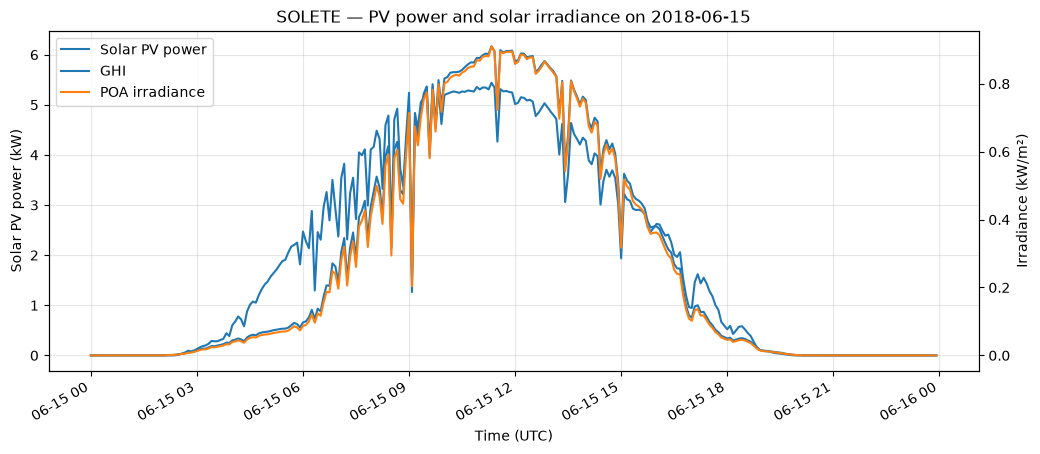

In [21]:
# ============================================================
# CELL 21 — COMPARE PV POWER WITH SOLAR IRRADIANCE
# ============================================================

import matplotlib.pyplot as plt

# Select one representative daytime period.
#
# We use the same day as before so that we can compare
# this plot directly with the elevation/PV plot.
sample_day = df.loc[
    "2018-06-15",
    [
        "P_Solar[kW]",
        "GHI[kW1m2]",
        "POA Irr[kW1m2]"
    ]
]

# Create a figure with one shared time axis
# and two y-axes.
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot solar PV power on the left axis.
ax1.plot(
    sample_day.index,
    sample_day["P_Solar[kW]"],
    label="Solar PV power"
)

ax1.set_xlabel("Time (UTC)")
ax1.set_ylabel("Solar PV power (kW)")

# Create the second y-axis.
ax2 = ax1.twinx()

# Plot GHI.
ax2.plot(
    sample_day.index,
    sample_day["GHI[kW1m2]"],
    label="GHI"
)

# Plot POA irradiance.
ax2.plot(
    sample_day.index,
    sample_day["POA Irr[kW1m2]"],
    label="POA irradiance"
)

ax2.set_ylabel("Irradiance (kW/m²)")

# Add a descriptive title.
plt.title(
    "SOLETE — PV power and solar irradiance on 2018-06-15"
)

# Add legends from both axes.
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

# Add a light grid.
ax1.grid(True, alpha=0.3)

# Improve time-axis readability.
fig.autofmt_xdate()

# Display the plot.
plt.show()

In [22]:
# ============================================================
# CELL 22 — CORRELATION BETWEEN SOLAR VARIABLES
# ============================================================

# Select the four variables we want to compare.
#
# We include:
#   - Solar PV power
#   - Global Horizontal Irradiance (GHI)
#   - Plane-of-Array irradiance (POA)
#   - Solar elevation
#
# Correlation values range from -1 to +1:
#
#   +1  -> very strong positive relationship
#    0  -> little/no linear relationship
#   -1  -> very strong negative relationship
#
# This is only an exploratory analysis.
# It does NOT imply that one variable causes another.
correlation_data = df[
    [
        "P_Solar[kW]",
        "GHI[kW1m2]",
        "POA Irr[kW1m2]",
        "Elevation[deg]"
    ]
]

# Calculate the Pearson correlation matrix.
correlation_matrix = correlation_data.corr()

# Display the correlation matrix.
correlation_matrix

,P_Solar[kW],GHI[kW1m2],POA Irr[kW1m2],Elevation[deg]
P_Solar[kW],1.000000,0.913074,0.995524,0.752715
GHI[kW1m2],0.913074,1.000000,0.925658,0.832412
POA Irr[kW1m2],0.995524,0.925658,1.000000,0.760385
Elevation[deg],0.752715,0.832412,0.760385,1.000000


In [23]:
# ============================================================
# CELL 23 — FULL DATASET CORRELATION MATRIX
# ============================================================

# Calculate Pearson correlation between all numerical
# variables in the 5-minute SOLETE dataset.
#
# Since all 11 SOLETE variables are numerical, this gives
# us an initial overview of their linear relationships.
#
# Important:
# Correlation does NOT imply causation.
#
# Also, some variables such as wind direction are circular,
# so ordinary Pearson correlation is not necessarily an
# appropriate final measure for them. We are using this
# only as exploratory analysis.

full_correlation_matrix = df.corr()

# Display the complete correlation matrix.
full_correlation_matrix

,TEMPERATURE[degC],HUMIDITY[%],WIND_SPEED[m1s],WIND_DIR[deg],GHI[kW1m2],POA Irr[kW1m2],P_Gaia[kW],P_Solar[kW],Pressure[mbar],Azimuth[deg],Elevation[deg]
TEMPERATURE[degC],1.000000,-0.465352,-0.056939,0.124086,0.500668,0.409575,-0.139374,0.391603,0.046567,0.069424,0.538318
HUMIDITY[%],-0.465352,1.000000,-0.125778,-0.095723,-0.611833,-0.602413,-0.075743,-0.601686,0.093785,-0.176524,-0.601901
WIND_SPEED[m1s],-0.056939,-0.125778,1.000000,0.375262,0.109615,0.132613,0.844912,0.142992,-0.024818,0.012884,0.142813
WIND_DIR[deg],0.124086,-0.095723,0.375262,1.000000,0.165456,0.153604,0.339974,0.156681,0.042362,0.011503,0.171334
GHI[kW1m2],0.500668,-0.611833,0.109615,0.165456,1.000000,0.925658,0.013380,0.913074,0.000403,-0.207131,0.832412
POA Irr[kW1m2],0.409575,-0.602413,0.132613,0.153604,0.925658,1.000000,0.041424,0.995524,0.005753,-0.120348,0.760385
P_Gaia[kW],-0.139374,-0.075743,0.844912,0.339974,0.013380,0.041424,1.000000,0.051586,-0.030546,0.024025,0.048090
P_Solar[kW],0.391603,-0.601686,0.142992,0.156681,0.913074,0.995524,0.051586,1.000000,0.005748,-0.118206,0.752715
Pressure[mbar],0.046567,0.093785,-0.024818,0.042362,0.000403,0.005753,-0.030546,0.005748,1.000000,-0.000302,-0.008573
Azimuth[deg],0.069424,-0.176524,0.012884,0.011503,-0.207131,-0.120348,0.024025,-0.118206,-0.000302,1.000000,-0.018982


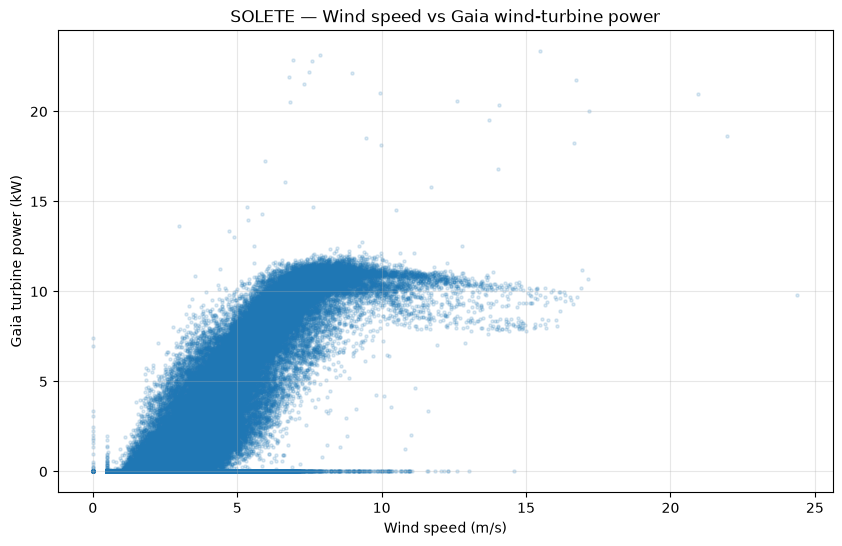

In [24]:
# ============================================================
# CELL 24 — WIND SPEED VS WIND TURBINE POWER
# ============================================================

import matplotlib.pyplot as plt

# Create a scatter plot of wind speed against
# wind-turbine power.
#
# Each point represents one 5-minute observation.
#
# We use a small point size and transparency because
# the dataset contains more than 130,000 observations,
# so many points will overlap.

plt.figure(figsize=(10, 6))

plt.scatter(
    df["WIND_SPEED[m1s]"],
    df["P_Gaia[kW]"],
    s=5,
    alpha=0.15
)

# Label the axes.
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Gaia turbine power (kW)")

# Add a descriptive title.
plt.title(
    "SOLETE — Wind speed vs Gaia wind-turbine power"
)

# Add a light grid to make the relationship easier to inspect.
plt.grid(True, alpha=0.3)

# Display the plot.
plt.show()

In [25]:
# ============================================================
# CELL 25 — INVESTIGATE HIGH GAIA TURBINE POWER VALUES
# ============================================================

# Select observations where Gaia turbine power is above 12 kW.
#
# From the scatter plot, the main dense power region appears
# to level off around approximately 10–12 kW.
#
# We are NOT declaring values above 12 kW invalid.
# This threshold is only being used to isolate observations
# that are clearly separated from the main data cloud.

high_gaia_power = df.loc[
    df["P_Gaia[kW]"] > 12,
    [
        "WIND_SPEED[m1s]",
        "WIND_DIR[deg]",
        "P_Gaia[kW]"
    ]
]

# Count these observations.
print("Number of Gaia power observations above 12 kW:")
print(len(high_gaia_power))

# Calculate their percentage of the complete dataset.
high_gaia_percentage = (
    len(high_gaia_power) / len(df) * 100
)

print("\nPercentage of complete dataset:")
print(f"{high_gaia_percentage:.4f}%")

# Display their power range.
print("\nHigh-power range:")
print(
    high_gaia_power["P_Gaia[kW]"].min(),
    "to",
    high_gaia_power["P_Gaia[kW]"].max()
)

# Show the observations with the highest turbine power.
#
# This lets us inspect their timestamps and corresponding
# wind-speed values.
print("\nHighest Gaia power observations:")

high_gaia_power.sort_values(
    "P_Gaia[kW]",
    ascending=False
).head(20)

Number of Gaia power observations above 12 kW:
51

Percentage of complete dataset:
0.0387%

High-power range:
12.00097 to 23.33053846153846

Highest Gaia power observations:


,WIND_SPEED[m1s],WIND_DIR[deg],P_Gaia[kW]
Timestamp,,,
2018-12-08 00:00:00+00:00,15.485953,560.197324,23.330538
2019-03-16 00:00:00+00:00,7.858333,286.836667,23.116615
2018-09-24 00:00:00+00:00,6.926000,297.323333,22.876445
2019-01-01 00:00:00+00:00,7.571000,245.646667,22.821806
2019-02-05 00:00:00+00:00,7.486000,202.756667,22.194719
2018-09-28 00:00:00+00:00,8.960000,291.970000,22.148933
2018-08-12 00:00:00+00:00,6.787333,275.326667,21.930482
2019-01-15 00:00:00+00:00,16.717057,593.053512,21.750007
2018-12-10 00:00:00+00:00,7.313667,276.946667,21.507853


In [26]:
# ============================================================
# CELL 26 — CHECK WHETHER HIGH GAIA POWER OCCURS AT MIDNIGHT
# ============================================================

# Define the same exploratory threshold used previously.
#
# We are NOT saying that values above 12 kW are automatically
# invalid. We are checking whether they have a suspicious
# relationship with the 00:00 UTC timestamp.
high_power_mask = df["P_Gaia[kW]"] > 12


# ------------------------------------------------------------
# 1. Count all observations above 12 kW
# ------------------------------------------------------------

total_high_power = high_power_mask.sum()

print("Total P_Gaia observations above 12 kW:")
print(total_high_power)


# ------------------------------------------------------------
# 2. Count high-power observations occurring exactly at
#    00:00 UTC
# ------------------------------------------------------------

midnight_mask = (
    (df.index.hour == 0)
    &
    (df.index.minute == 0)
)

high_power_at_midnight = (
    high_power_mask
    &
    midnight_mask
).sum()

print("\nHigh-power observations occurring at exactly 00:00 UTC:")
print(high_power_at_midnight)


# ------------------------------------------------------------
# 3. Calculate what percentage of high-power observations
#    occur at midnight
# ------------------------------------------------------------

if total_high_power > 0:
    midnight_percentage = (
        high_power_at_midnight
        / total_high_power
        * 100
    )

    print("\nPercentage of >12 kW observations occurring at midnight:")
    print(f"{midnight_percentage:.2f}%")


# ------------------------------------------------------------
# 4. Compare maximum Gaia power at midnight vs all other times
# ------------------------------------------------------------

midnight_max_power = df.loc[
    midnight_mask,
    "P_Gaia[kW]"
].max()

non_midnight_max_power = df.loc[
    ~midnight_mask,
    "P_Gaia[kW]"
].max()

print("\nMaximum P_Gaia at 00:00 UTC:")
print(midnight_max_power)

print("\nMaximum P_Gaia outside 00:00 UTC:")
print(non_midnight_max_power)

Total P_Gaia observations above 12 kW:
51

High-power observations occurring at exactly 00:00 UTC:
35

Percentage of >12 kW observations occurring at midnight:
68.63%

Maximum P_Gaia at 00:00 UTC:
23.33053846153846

Maximum P_Gaia outside 00:00 UTC:
12.509403333333333


In [27]:
# ============================================================
# CELL 27 — INSPECT GAIA POWER AROUND A MIDNIGHT SPIKE
# ============================================================

# The largest Gaia power value in the dataset occurs at:
#
#   2018-12-08 00:00 UTC
#
# We inspect 30 minutes before and after this timestamp
# to determine whether the high value is part of a smooth
# physical pattern or an isolated midnight jump.
#
# We include:
#   - wind speed
#   - wind direction
#   - Gaia turbine power
#
# The original dataset is NOT being modified.

gaia_midnight_window = df.loc[
    "2018-12-07 23:30:00+00:00":
    "2018-12-08 00:30:00+00:00",
    [
        "WIND_SPEED[m1s]",
        "WIND_DIR[deg]",
        "P_Gaia[kW]"
    ]
]

print(
    "Wind conditions and Gaia power around "
    "2018-12-08 00:00 UTC:"
)

gaia_midnight_window

Wind conditions and Gaia power around 2018-12-08 00:00 UTC:


,WIND_SPEED[m1s],WIND_DIR[deg],P_Gaia[kW]
Timestamp,,,
2018-12-07 23:30:00+00:00,8.243333,267.410000,11.013980
2018-12-07 23:35:00+00:00,8.768333,270.590000,11.488640
2018-12-07 23:40:00+00:00,8.828000,268.490000,11.216943
2018-12-07 23:45:00+00:00,8.767000,271.646667,11.498637
2018-12-07 23:50:00+00:00,7.774333,267.076667,11.305783
2018-12-07 23:55:00+00:00,7.612000,266.596667,10.959943
2018-12-08 00:00:00+00:00,15.485953,560.197324,23.330538
2018-12-08 00:05:00+00:00,7.339667,261.680000,11.373940
2018-12-08 00:10:00+00:00,7.795667,268.310000,10.907083


In [28]:
# ============================================================
# CELL 28 — CORRECTED MIDNIGHT VS NEIGHBOR COMPARISON
# ============================================================

import numpy as np


# ------------------------------------------------------------
# PURPOSE
# ------------------------------------------------------------
#
# We previously compared midnight observations with the
# average of their immediate neighbors:
#
#     23:55 and 00:05
#
# That approach is appropriate for ordinary numerical
# variables such as:
#
#     - pressure
#     - wind speed
#     - turbine power
#
# However, WIND DIRECTION is a circular variable.
#
# Example:
#
#     359° and 1°
#
# are only 2° apart physically, even though their ordinary
# numerical difference is 358°.
#
# Therefore:
#
#   1. Linear variables are handled normally.
#   2. Wind direction is handled separately using
#      circular mathematics.
#
# The original dataset is NOT modified.


# ------------------------------------------------------------
# 1. IDENTIFY EXACT MIDNIGHT OBSERVATIONS
# ------------------------------------------------------------

midnight_mask = (
    (df.index.hour == 0)
    &
    (df.index.minute == 0)
)


# ============================================================
# PART A — LINEAR VARIABLES
# ============================================================

linear_variables = [
    "Pressure[mbar]",
    "WIND_SPEED[m1s]",
    "P_Gaia[kW]"
]


# Average the observations immediately before and after
# each timestamp.
linear_neighbor_average = (
    df[linear_variables].shift(1)
    +
    df[linear_variables].shift(-1)
) / 2


# Calculate the absolute difference between the actual
# observation and its local neighbor average.
linear_absolute_difference = (
    df[linear_variables]
    -
    linear_neighbor_average
).abs()


# Keep only the midnight rows.
midnight_linear_difference = (
    linear_absolute_difference.loc[midnight_mask]
)


print("Midnight differences for linear variables:")

display(
    midnight_linear_difference
    .describe()
    .T
)


# ============================================================
# PART B — CIRCULAR WIND DIRECTION
# ============================================================

# First wrap all wind-direction values into the conventional
# range:
#
#       0 <= angle < 360
#
# This is a diagnostic Series only.
# The original WIND_DIR[deg] column remains unchanged.

wind_direction_wrapped = (
    df["WIND_DIR[deg]"] % 360
)


# Convert angles from degrees to radians because numpy's
# sine and cosine functions operate in radians.
wind_radians = np.deg2rad(
    wind_direction_wrapped
)


# Get the previous and next wind directions.
previous_angle = wind_radians.shift(1)
next_angle = wind_radians.shift(-1)


# ------------------------------------------------------------
# CALCULATE CIRCULAR MEAN OF THE TWO NEIGHBORS
# ------------------------------------------------------------
#
# Instead of:
#
#     (angle_1 + angle_2) / 2
#
# we average their sine and cosine components.

mean_sin = (
    np.sin(previous_angle)
    +
    np.sin(next_angle)
) / 2

mean_cos = (
    np.cos(previous_angle)
    +
    np.cos(next_angle)
) / 2


# Convert the circular mean back to degrees.
circular_neighbor_mean = (
    np.rad2deg(
        np.arctan2(
            mean_sin,
            mean_cos
        )
    )
    % 360
)


# ------------------------------------------------------------
# CALCULATE SMALLEST ANGULAR DIFFERENCE
# ------------------------------------------------------------
#
# This produces a distance between:
#
#       0° and 180°
#
# Example:
#
#     midnight = 359°
#     neighbor mean = 1°
#
# gives:
#
#     angular difference = 2°
#
# rather than 358°.

wind_direction_difference = np.abs(
    (
        wind_direction_wrapped
        - circular_neighbor_mean
        + 180
    )
    % 360
    - 180
)


# Keep midnight observations only.
midnight_wind_difference = (
    wind_direction_difference.loc[
        midnight_mask
    ]
)


print("\nCircular midnight differences for wind direction:")

print(
    midnight_wind_difference
    .describe()
)

Midnight differences for linear variables:


,count,mean,std,min,25%,50%,75%,max
Pressure[mbar],456.0,1000.105435,0.139344,999.733505,1000.000000,1000.000000,1000.209493,1000.572495
WIND_SPEED[m1s],456.0,1.316887,2.097789,0.000000,0.099667,0.346333,1.513426,11.764147
P_Gaia[kW],456.0,1.178271,2.626930,0.000000,0.000000,0.071224,0.731848,13.313825



Circular midnight differences for wind direction:
count    456.000000
mean      41.922027
std       56.543179
min        0.000000
25%        1.701667
50%        5.739167
75%       82.133038
max      179.216360
Name: WIND_DIR[deg], dtype: float64


In [29]:
# ============================================================
# CELL 29 — CORRECTED MIDNIGHT DISCONTINUITIES FOR ALL VARIABLES
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# PURPOSE
# ------------------------------------------------------------
#
# We want a compact summary of how strongly each SOLETE
# variable changes at exactly 00:00 UTC compared with its
# immediately surrounding observations.
#
# For ordinary numerical variables, we compare the midnight
# value with the average of:
#
#       previous observation -> 23:55
#       next observation     -> 00:05
#
# However, angular variables must be treated differently.
#
# Circular variables:
#
#   - WIND_DIR[deg]
#   - Azimuth[deg]
#
# For these variables, we use:
#
#   - circular mean of the two neighboring angles
#   - smallest angular difference (0° to 180°)
#
# The original dataset is NOT modified.


# ------------------------------------------------------------
# 1. IDENTIFY EXACT MIDNIGHT OBSERVATIONS
# ------------------------------------------------------------

midnight_mask = (
    (df.index.hour == 0)
    &
    (df.index.minute == 0)
)


# ============================================================
# PART A — LINEAR VARIABLES
# ============================================================

linear_variables = [
    "TEMPERATURE[degC]",
    "HUMIDITY[%]",
    "WIND_SPEED[m1s]",
    "GHI[kW1m2]",
    "POA Irr[kW1m2]",
    "P_Gaia[kW]",
    "P_Solar[kW]",
    "Pressure[mbar]",
    "Elevation[deg]"
]


# Calculate the ordinary numerical average of the
# immediately previous and next observations.
linear_neighbor_average = (
    df[linear_variables].shift(1)
    +
    df[linear_variables].shift(-1)
) / 2


# Calculate absolute deviation from the local
# neighbor average.
linear_difference = (
    df[linear_variables]
    -
    linear_neighbor_average
).abs()


# Keep midnight rows only.
midnight_linear_difference = (
    linear_difference.loc[midnight_mask]
)


# Create summary statistics.
linear_summary = pd.DataFrame({

    "median_abs_difference":
        midnight_linear_difference.median(),

    "75th_percentile_abs_difference":
        midnight_linear_difference.quantile(0.75),

    "max_abs_difference":
        midnight_linear_difference.max()
})


# ============================================================
# PART B — CIRCULAR VARIABLES
# ============================================================

circular_variables = [
    "WIND_DIR[deg]",
    "Azimuth[deg]"
]


def circular_neighbor_difference(series):
    """
    Calculate the circular difference between each angular
    observation and the circular mean of its immediate
    previous and next observations.

    Parameters
    ----------
    series : pandas.Series
        Angular values measured in degrees.

    Returns
    -------
    pandas.Series
        Smallest angular difference in degrees.

        Every result lies between 0° and 180°.
    """

    # Wrap angles into the conventional [0, 360) range.
    wrapped = series % 360

    # Convert degrees to radians.
    radians = np.deg2rad(wrapped)

    # Previous and next angular observations.
    previous_angle = radians.shift(1)
    next_angle = radians.shift(-1)

    # --------------------------------------------------------
    # Circular mean of the two neighboring angles
    # --------------------------------------------------------

    mean_sin = (
        np.sin(previous_angle)
        +
        np.sin(next_angle)
    ) / 2

    mean_cos = (
        np.cos(previous_angle)
        +
        np.cos(next_angle)
    ) / 2

    circular_mean = (
        np.rad2deg(
            np.arctan2(
                mean_sin,
                mean_cos
            )
        )
        % 360
    )

    # --------------------------------------------------------
    # Smallest angular separation
    # --------------------------------------------------------

    difference = np.abs(
        (
            wrapped
            - circular_mean
            + 180
        )
        % 360
        - 180
    )

    return difference


# Store the midnight circular differences.
midnight_circular_difference = pd.DataFrame(
    index=df.index[midnight_mask]
)


for variable in circular_variables:

    circular_difference = (
        circular_neighbor_difference(
            df[variable]
        )
    )

    midnight_circular_difference[variable] = (
        circular_difference.loc[midnight_mask]
    )


# Create summary statistics.
circular_summary = pd.DataFrame({

    "median_abs_difference":
        midnight_circular_difference.median(),

    "75th_percentile_abs_difference":
        midnight_circular_difference.quantile(0.75),

    "max_abs_difference":
        midnight_circular_difference.max()
})


# ============================================================
# PART C — COMBINE BOTH RESULTS
# ============================================================

midnight_summary_corrected = pd.concat(
    [
        linear_summary,
        circular_summary
    ]
)


# Restore the original dataset column order so that the
# output is easier to compare with previous summaries.
midnight_summary_corrected = (
    midnight_summary_corrected
    .reindex(df.columns)
)


print(
    "Corrected midnight discontinuity summary "
    "for all variables:"
)

midnight_summary_corrected

Corrected midnight discontinuity summary for all variables:


,median_abs_difference,75th_percentile_abs_difference,max_abs_difference
TEMPERATURE[degC],0.049583,5.065949,22.266785
HUMIDITY[%],0.000000,0.800000,1.008863
WIND_SPEED[m1s],0.346333,1.513426,11.764147
WIND_DIR[deg],5.739167,82.133038,179.216360
GHI[kW1m2],0.000000,0.000000,0.000000
POA Irr[kW1m2],0.000000,0.000000,0.001166
P_Gaia[kW],0.071224,0.731848,13.313825
P_Solar[kW],0.000000,0.000000,0.008396
Pressure[mbar],1000.000000,1000.209493,1000.572495
Azimuth[deg],0.000000,0.000000,0.000000


## 5-Minute EDA — Main Findings

The exploratory analysis of the 5-minute SOLETE dataset produced the
following main observations.

### Dataset Structure

- The dataset contains **131,617 observations** and **11 measured variables**.
- Temporal coverage extends from **June 2018 to September 2019**.
- No missing values were found.
- No duplicate timestamps were found.
- All timestamps are already stored in chronological order.
- Every consecutive observation is separated by exactly **5 minutes**.
- No unexpected sampling intervals were detected.

### Solar-Power Behaviour

- Solar generation contains many legitimate zero observations, primarily
  associated with periods of low or no solar availability.
- Solar elevation follows a clear daily astronomical pattern.
- `Elevation[deg]` is represented as zero during substantial portions of
  the day and should therefore not automatically be interpreted as a
  conventional signed solar-elevation angle.
- Solar power has very strong same-timestamp relationships with irradiance:
  - `P_Solar[kW]` vs `POA Irr[kW1m2]`: approximately **0.996**
  - `P_Solar[kW]` vs `GHI[kW1m2]`: approximately **0.913**
  - `P_Solar[kW]` vs `Elevation[deg]`: approximately **0.753**
- Visual inspection also showed that short-term fluctuations in PV output
  broadly follow fluctuations in irradiance.

### Wind-Power Behaviour

- Wind turbine power has a strong relationship with wind speed:
  - `P_Gaia[kW]` vs `WIND_SPEED[m1s]`: approximately **0.845**
- The wind-speed/power relationship is clearly nonlinear and resembles a
  turbine power curve.
- Zero wind-power observations are common and should not automatically be
  treated as missing data.
- Extreme Gaia power values are strongly concentrated around the
  **00:00 UTC daily boundary**.

### Data-Quality Observations

- **103 wind-direction observations** exceed 360 degrees.
- Applying modulo 360 to a diagnostic copy maps all wind-direction values
  into the conventional `[0°, 360°)` interval.
- The original wind-direction values were not modified.
- Because wind direction is circular, ordinary linear differences are not
  appropriate for angular comparisons.
- Midnight wind-direction discontinuities were therefore re-evaluated using
  circular statistics and the smallest angular separation.

- Pressure contains a highly systematic daily-boundary anomaly.
- **456 pressure observations** exceed 1100 mbar.
- These suspicious observations occur at **00:00 UTC**.
- The midnight pressure value differs from its neighbouring observations by
  approximately **1000 mbar**, strongly indicating a systematic processing
  artifact rather than a physical atmospheric change.

- Some midnight observations also contain unusually large discontinuities in:
  - wind speed,
  - wind direction,
  - Gaia turbine power,
  - temperature,
  - and humidity.

- The `HUMIDITY[%]` values do not resemble conventional percentage-point
  relative humidity values on a 0–100 scale.
  The original values are preserved, and the exact encoding/unit should be
  verified before humidity is used in the final forecasting pipeline.

### Correlation Interpretation Note

The correlations calculated in this notebook are **descriptive
same-timestamp relationships** and should not be interpreted directly as
forecasting performance.

In particular:

- irradiance and PV power contain many simultaneous low or zero nighttime
  observations, which can strengthen whole-dataset Pearson correlations;
- contemporaneous `GHI` and `POA Irr` measurements may not be available for
  the future timestamp being predicted;
- using information from the target timestamp that would not realistically
  be known at forecast time could introduce **information leakage**.

The forecasting experiments will therefore distinguish between:

1. variables genuinely available at the forecast origin,
2. lagged historical measurements,
3. deterministic future variables such as calendar and astronomical features,
4. and variables whose future values would require their own forecast.

### Data-Handling Decision

The original SOLETE measurements remain unchanged during EDA.

No suspicious source values were silently corrected, removed, or overwritten.

Potential preprocessing strategies will be evaluated explicitly during the
modelling stage. These may include:

- excluding problematic variables,
- treating identified anomalous observations as missing,
- creating cleaned diagnostic versions,
- applying circular feature engineering to wind direction,
- and comparing raw versus cleaned forecasting pipelines.

### Overall 5-Minute Assessment

The 5-minute dataset is structurally clean and preserves meaningful
short-term solar and wind behaviour.

Its main concerns are not missing timestamps or missing measurements, but
rather several systematic or representation-related issues, particularly:

- midnight pressure artifacts,
- occasional daily-boundary anomalies,
- circular wind-direction representation,
- uncertain humidity encoding,
- and the potential for information leakage when using contemporaneous
  irradiance measurements.

These issues are manageable provided they are handled explicitly in the
forecasting methodology.

### Next Step

The remaining SOLETE resolutions will be examined using the same essential
structural checks.

After completing the resolution-specific EDA notebooks, a dedicated
cross-resolution comparison will be used to determine:

- which characteristics are common across resolutions,
- which anomalies are resolution-specific,
- how target and feature distributions change with sampling resolution,
- and which temporal resolution is most appropriate for the main forecasting
  experiments.